# DNN hw1

The purpose of this notebook is to collect all the results (mainly pictures and tables), so that they can further be used in the report. There isn't much commentary in the notebook itself.

## Handle imports & installs

In [1]:
# !wget https://github.com/marcin119a/data/raw/refs/heads/main/data_gsn.zip
# !unzip data_gsn.zip &> /dev/null
# !rm data_gsn.zip




In [2]:
import torch 
torch.manual_seed(1)

In [3]:
from logging import getLogger
logger = getLogger("dnn_solver")
# we're ok with excessive logging
logger.setLevel("INFO")

## Prepare the Torch dataframe

In [4]:
from dnn_solver.dataset import IMGDataset


dataset = IMGDataset(train=None)
dataset

--- Logging error ---
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/logging/__init__.py", line 1100, in emit
    msg = self.format(record)
  File "/usr/local/lib/python3.10/logging/__init__.py", line 943, in format
    return fmt.format(record)
  File "/usr/local/lib/python3.10/logging/__init__.py", line 678, in format
    record.message = record.getMessage()
  File "/usr/local/lib/python3.10/logging/__init__.py", line 368, in getMessage
    msg = msg % self.args
TypeError: not all arguments converted during string formatting
Call stack:
  File "/usr/local/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/local/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/gemlorg/projects/studies/fifth-year/DNN/.venv/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/gemlorg/projects/studies/fifth-year

Dataset IMGDataset
    Number of datapoints: 10000
    Root location: ./data

Verify that the images were loaded correctly:

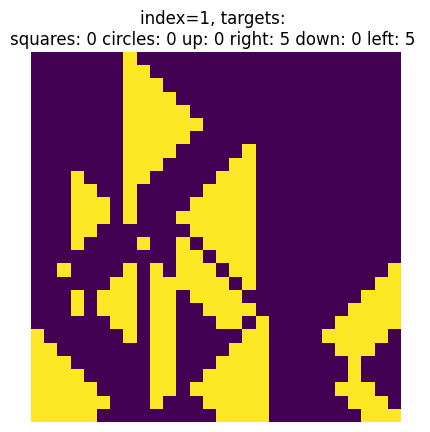

In [5]:
dataset.repr_item(1)

## Data Analysis

We focus on the labels df, verify the distribution of classes etc. 


In [6]:
labels_df = dataset.get_labels()

In [7]:
labels_df.describe()

,squares,circles,up,right,down,left
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.65740,1.714900,1.653000,1.677000,1.685700,1.612000
std,2.62909,2.656073,2.619557,2.627539,2.641101,2.574979
min,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.00000,3.000000,3.000000,3.000000,3.000000,3.000000
max,8.00000,8.000000,8.000000,8.000000,8.000000,8.000000


In [8]:
# assert 1 not in df 
for col in labels_df.columns:
    assert 1 not in labels_df[col].values

It seems the max value for each col is 8, therefore there can be at most 6 * 5 / 2 * 7 = 105 classes represented, not 135 as described in the assignment. This is important because reducing the number of classes 1. reduces loss 2. will not lead to an unexpected behaviour when evaluating on a different dataset that has 1-9 splits. Therefore, we will proceed with the assumption that there should be 105 classes and not 135.

In [ ]:
# later on we should use utils only
from dnn_solver.constants import TARGET_COL_NAMES


def get_configuration(row: dict) -> int: 
    #get names of columns that are not 0 
    selected_names = list(filter(lambda x: row[x] > 0, TARGET_COL_NAMES))
    # assert there are two of them 
    assert len(selected_names) == 2, f"Expected 2 non-zero columns, got {row}, selected_names={selected_names}"
    # get their indices 
    indices = list(map(lambda x: TARGET_COL_NAMES.index(x), selected_names))
    # sort the indices 
    indices.sort()
    # calculate the idx 
    idx = 0
    indices = sorted(TARGET_COL_NAMES.index(name) for name in selected_names)
    a, b = indices  # 0 <= a < b < n
    n = len(TARGET_COL_NAMES)
    pair_index = a * (2 * n - a - 1) // 2 + (b - a - 1)  # in [0, 14] for n=6
    idx += pair_index * 7
    idx += row[TARGET_COL_NAMES[indices[0]]] - 2
    return idx 

# Unit test for get_configuration
def make_row(i, j, v):
    """
    Build a row dict with exactly two non-zero columns:
    - column i has count v (2..9)
    - column j has count 2
    """
    row = {name: 0 for name in TARGET_COL_NAMES}
    row[TARGET_COL_NAMES[i]] = v
    row[TARGET_COL_NAMES[j]] = 10 - v
    return row

def test_get_configuration_105_unique_classes():
    seen = set()
    count = 0

    for i in range(len(TARGET_COL_NAMES)):
        for j in range(i + 1, len(TARGET_COL_NAMES)):
            for v in range(2, 9):  # 2..8 (7 values)
                count += 1
                row = make_row(i, j, v)
                cfg = get_configuration(row)

                # config index should live in [0, 120)
                assert 0 <= cfg < 105
                seen.add(cfg)

    # 6 choose 2 = 15 pairs, 15 * 7 = 105
    assert len(seen) == 105, f"Expected 105 unique configurations, got {len(seen)}"
    assert count == 105

test_get_configuration_105_unique_classes()
labels_df['configuration'] = labels_df.apply(get_configuration, axis=1)


array([[<Axes: title={'center': 'configuration'}>]], dtype=object)

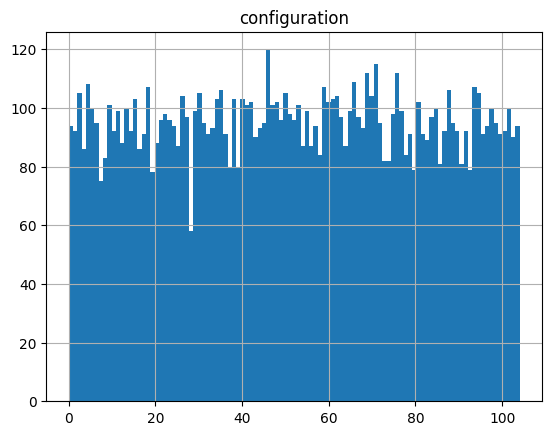

In [10]:
labels_df[['configuration']].hist(bins=105)

In [11]:
config_dist = labels_df["configuration"].value_counts().sort_index()
config_dist.describe()

count    105.000000
mean      95.238095
std        9.364955
min       58.000000
25%       91.000000
50%       95.000000
75%      102.000000
max      120.000000
Name: count, dtype: float64

All of the classes seem to be pretty well represented (except maybe for one, but it still doesn't seem like an issue). Here we've checked for the entire dataset, assuming the train/test split required by the assignment definition was done randomly, the same should hold for the train/test datasets. 

The plotted embeddings are not included in the notebook as they don't really tell any info.
    

## Training setup

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [13]:
from dnn_solver import DataAugmentation
from torch.utils.data import DataLoader

from dnn_solver.types import BrightnessContrastAugmentationConfig, DataAugmentationConfig, FlipAugmentationConfig, GaussianNoiseAugmentationConfig, RotationAugmentationConfig


config = DataAugmentationConfig(
    flip=FlipAugmentationConfig(probability=0.4, horizontal=True, vertical=True),
    rotation=RotationAugmentationConfig(probability=0.4),
    gaussian_noise=GaussianNoiseAugmentationConfig(probability=0.1, mean=0.0, std=0.05),
    brightness_contrast=BrightnessContrastAugmentationConfig(probability=0.1, brightness=0.1, contrast=0.1),
)

train_dataset = IMGDataset(train=True, transform=DataAugmentation(config))
val_dataset   = IMGDataset(train=False)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=1000, shuffle=False)


--- Logging error ---
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/logging/__init__.py", line 1100, in emit
    msg = self.format(record)
  File "/usr/local/lib/python3.10/logging/__init__.py", line 943, in format
    return fmt.format(record)
  File "/usr/local/lib/python3.10/logging/__init__.py", line 678, in format
    record.message = record.getMessage()
  File "/usr/local/lib/python3.10/logging/__init__.py", line 368, in getMessage
    msg = msg % self.args
TypeError: not all arguments converted during string formatting
Call stack:
  File "/usr/local/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/local/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/gemlorg/projects/studies/fifth-year/DNN/.venv/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/gemlorg/projects/studies/fifth-year

We're asked to run three experiments, only difference is the lambda/ use cls loss

In [14]:
from dnn_solver.net import MultiTaskNet
from dnn_solver.trainer import MultiTaskTrainer

# we assume that values are in 2..8, instead of 1..9 as in the original assignment statement, change to 1..9 if needed
VALUES_MIN = 2
VALUES_MAX = 8
img_dir = "./img"

def run_experiment(lambda_cnt: float, use_cls_loss: bool, *, epochs: int = 100, weight_decay: float = 1e-4, log_freq: int = 50, patience: int = 15):
    use_cls_loss = use_cls_loss
    model = MultiTaskNet(num_classes=15 * (VALUES_MAX - VALUES_MIN + 1), dropout_p=0.3).to(device)
    trainer = MultiTaskTrainer(
        model=model,
        trainloader=train_loader,
        testloader=val_loader,
        device=device,
        lambda_cnt=lambda_cnt,
        use_cls_loss=use_cls_loss,
        values_min=VALUES_MIN,  
        values_max=VALUES_MAX,
    )
    metrics = trainer.train(
        epochs=epochs,
        lr=1e-3,
        weight_decay=weight_decay,
        log_freq=log_freq,
        patience=patience,
    )
    trainer.plot_learning_curves(save_dir=img_dir)
    return metrics


[INFO] epoch    1, batch    50, loss 4.657
[INFO] epoch    1, batch   100, loss 4.656
[INFO] epoch    1 evaluation: loss_total=4.6547, accuracy=0.0040
[INFO]                loss_cls=4.6547, loss_reg=1.4999
[INFO] epoch    2, batch    50, loss 4.656
[INFO] epoch    2, batch   100, loss 4.655
[INFO] epoch    2 evaluation: loss_total=4.6554, accuracy=0.0140
[INFO]                loss_cls=4.6554, loss_reg=1.5000
[INFO] epoch    3, batch    50, loss 4.653
[INFO] epoch    3, batch   100, loss 4.654
[INFO] epoch    3 evaluation: loss_total=4.6546, accuracy=0.0100
[INFO]                loss_cls=4.6546, loss_reg=1.5000
[INFO] epoch    4, batch    50, loss 4.654
[INFO] epoch    4, batch   100, loss 4.654
[INFO] epoch    4 evaluation: loss_total=4.6554, accuracy=0.0110
[INFO]                loss_cls=4.6554, loss_reg=1.5000
[INFO] epoch    5, batch    50, loss 4.653
[INFO] epoch    5, batch   100, loss 4.654
[INFO] epoch    5 evaluation: loss_total=4.6549, accuracy=0.0110
[INFO]                los

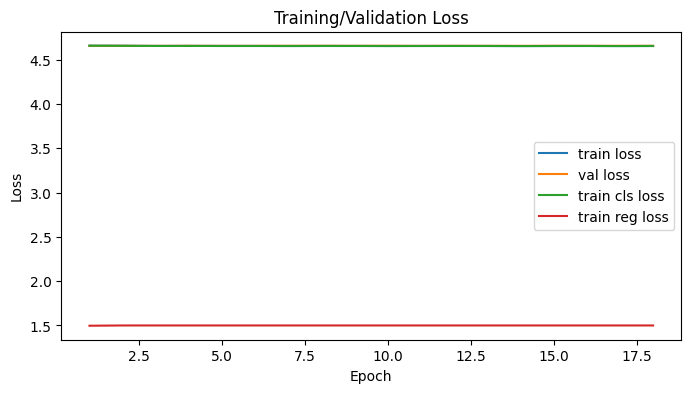

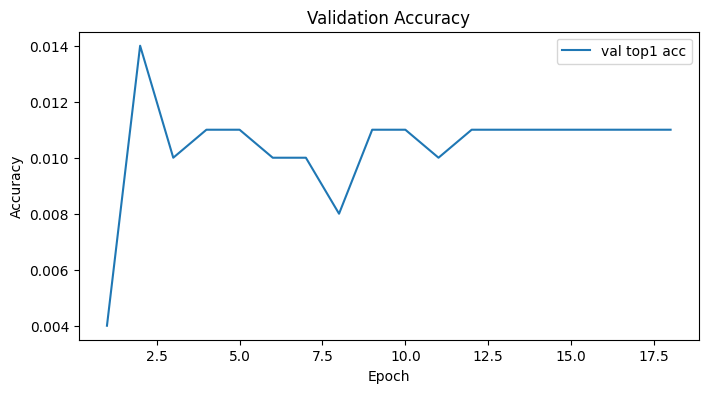

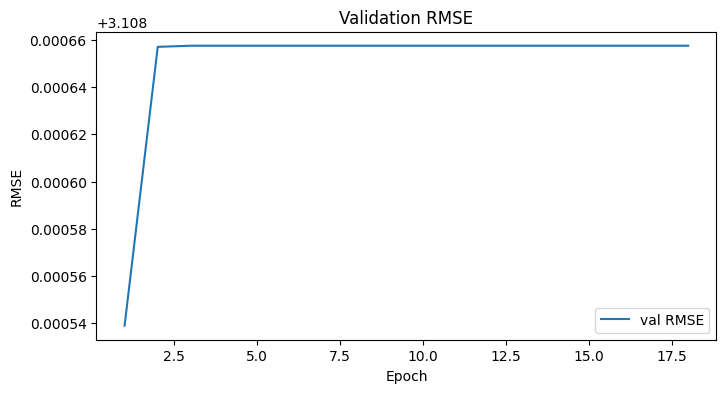

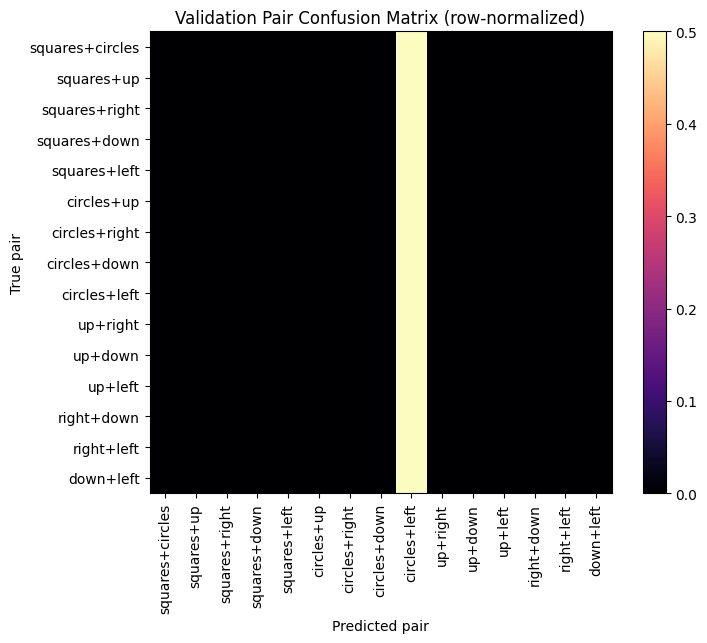

[Loss] loss_total=4.6546, loss_cls=4.6546, loss_reg=1.5000; 
[Classification] top1=0.0100, macro_f1=0.0002, lowest_acc_pairs={'squares+circles': 0.0, 'squares+up': 0.0, 'squares+right': 0.0, 'squares+down': 0.0, 'squares+left': 0.0}; 
[Regression] rmse_overall=3.1087, mae_overall=1.6667, rmse_per_dim={'squares': 3.0966, 'circles': 3.0976, 'up': 3.1672, 'right': 3.1826, 'down': 3.0674, 'left': 3.0406}, mae_per_dim={'squares': 1.651, 'circles': 1.659, 'up': 1.719, 'right': 1.701, 'down': 1.631, 'left': 1.639}

In [15]:
run_experiment(lambda_cnt=0, use_cls_loss=True)

In [ ]:
run_experiment(lambda_cnt=1.0, use_cls_loss=False)

[INFO] epoch    1, batch    50, loss 1.424
[INFO] epoch    1, batch   100, loss 1.415
[INFO] epoch    1 evaluation: loss_total=1.3422, accuracy=0.0110
[INFO]                loss_cls=4.6540, loss_reg=1.3422
[INFO] epoch    2, batch    50, loss 1.317
[INFO] epoch    2, batch   100, loss 1.193
[INFO] epoch    2 evaluation: loss_total=1.0599, accuracy=0.0110
[INFO]                loss_cls=4.6540, loss_reg=1.0599
[INFO] epoch    3, batch    50, loss 0.977
[INFO] epoch    3, batch   100, loss 0.891
[INFO] epoch    3 evaluation: loss_total=0.7581, accuracy=0.0110
[INFO]                loss_cls=4.6540, loss_reg=0.7581
[INFO] epoch    4, batch    50, loss 0.761
[INFO] epoch    4, batch   100, loss 0.682
[INFO] epoch    4 evaluation: loss_total=0.5739, accuracy=0.0110
[INFO]                loss_cls=4.6540, loss_reg=0.5739
[INFO] epoch    5, batch    50, loss 0.567
[INFO] epoch    5, batch   100, loss 0.528
[INFO] epoch    5 evaluation: loss_total=0.3714, accuracy=0.0110
[INFO]                los

epoch    1, batch    50, loss 6.083
epoch    1, batch   100, loss 6.073
epoch    1 evaluation: loss_total=6.0204, accuracy=0.0110
               loss_cls=4.6127, loss_reg=1.4077
epoch    2, batch    50, loss 5.812
epoch    2, batch   100, loss 5.129
epoch    2 evaluation: loss_total=4.5748, accuracy=0.0600
               loss_cls=3.5072, loss_reg=1.0677
epoch    3, batch    50, loss 4.566
epoch    3, batch   100, loss 4.353
epoch    3 evaluation: loss_total=4.0352, accuracy=0.1080
               loss_cls=3.1561, loss_reg=0.8791
epoch    4, batch    50, loss 4.000
epoch    4, batch   100, loss 3.741
epoch    4 evaluation: loss_total=3.3287, accuracy=0.1440
               loss_cls=2.6140, loss_reg=0.7146
epoch    5, batch    50, loss 3.409
epoch    5, batch   100, loss 3.323
epoch    5 evaluation: loss_total=3.2165, accuracy=0.1880
               loss_cls=2.5332, loss_reg=0.6833
epoch    6, batch    50, loss 3.152
epoch    6, batch   100, loss 2.979
epoch    6 evaluation: loss_total=2.75

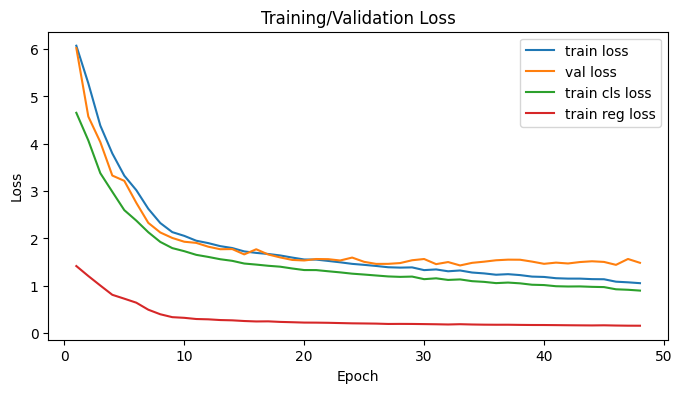

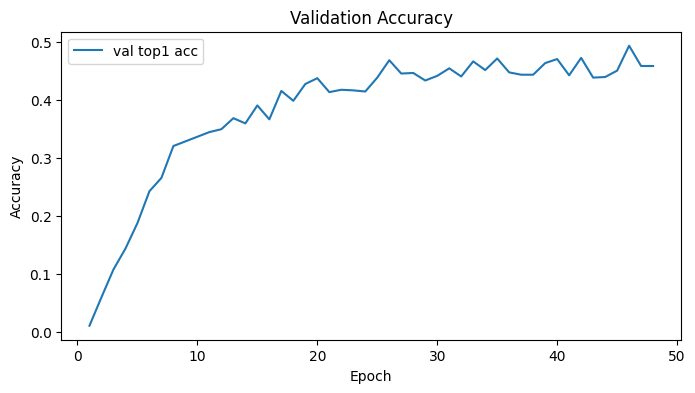

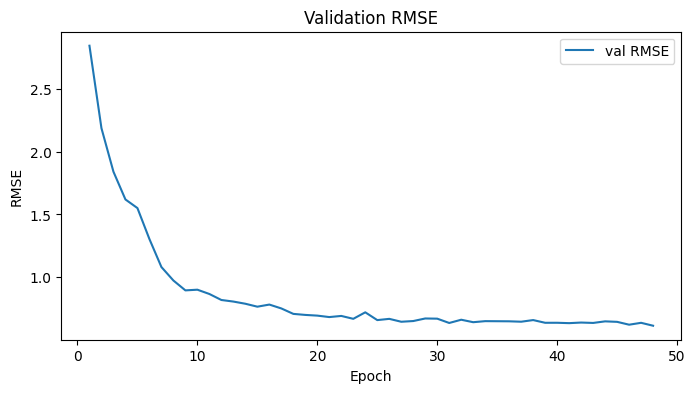

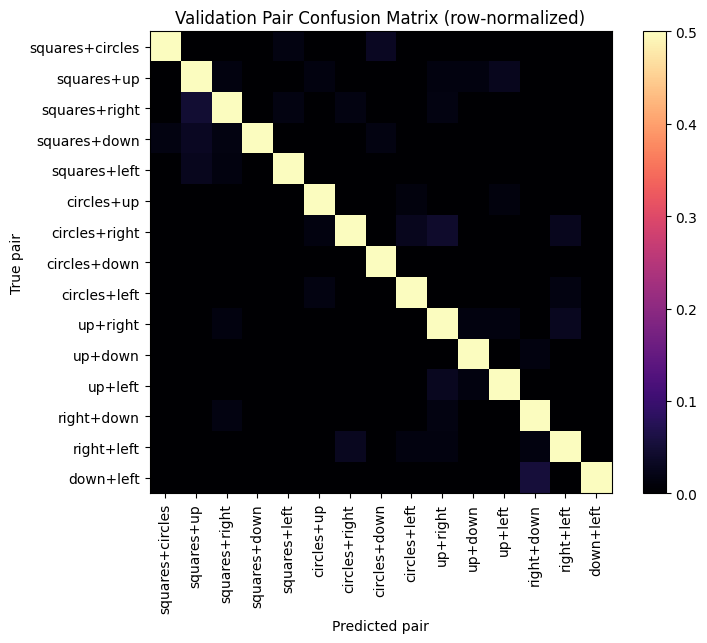

[Loss] loss_total=1.4299, loss_cls=1.2603, loss_reg=0.1696; 
[Classification] top1=0.4670, macro_f1=0.4364, worst_pairs={'circles+right': 0.8873, 'squares+right': 0.9048, 'squares+up': 0.9143, 'squares+down': 0.9219, 'up+right': 0.9231}; 
[Regression] rmse_overall=0.6414, mae_overall=0.3576, rmse_per_dim={'squares': 0.5177, 'circles': 0.6497, 'up': 0.628, 'right': 0.6776, 'down': 0.6659, 'left': 0.7096}, mae_per_dim={'squares': 0.2885, 'circles': 0.3388, 'up': 0.3617, 'right': 0.3836, 'down': 0.3631, 'left': 0.4097}

In [ ]:
run_experiment(lambda_cnt=3.0, use_cls_loss=True)